# Exploratory Data Analysis

In [1]:
CSV_PATH = "../data/raw/csv/"

### Local CSV files

I will start the analysis by inspecting the CSV files. I will focus here on the missingness and distribution of numeric and descriptive data, as well as visualization of the customer's locations, competitors and POIs on the analysis area.

#### ds_locations

In [2]:
import pandas as pd
ds_locations = pd.read_csv(CSV_PATH + "ds_locations.csv")

In [3]:
ds_locations

,location_id,lat,lng,monthly_revenue
0,LOC_001,50.226272,19.072973,245633.74
1,LOC_002,50.299999,18.674625,333393.33
2,LOC_003,50.042894,19.968676,296109.69
3,LOC_004,50.130954,19.607709,197099.19
4,LOC_005,50.351594,18.894944,292786.56
5,LOC_006,50.016769,20.010290,174307.46
6,LOC_007,50.283699,19.017317,526630.01
7,LOC_008,50.147486,18.840116,156433.13
8,LOC_009,50.303099,18.678924,335019.41
9,LOC_010,50.347639,18.921651,355288.71


In [4]:
ds_locations.info()
ds_locations.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   location_id      50 non-null     object 
 1   lat              50 non-null     float64
 2   lng              50 non-null     float64
 3   monthly_revenue  50 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.7+ KB


,lat,lng,monthly_revenue
count,50.000000,50.000000,50.000000
mean,50.189476,19.301192,275269.401400
std,0.122854,0.521044,108052.296936
min,49.965208,18.548470,50000.000000
25%,50.096988,18.900723,204756.427500
50%,50.214888,19.061025,260956.905000
75%,50.287100,19.925615,318203.880000
max,50.441998,20.081011,623866.240000


In [5]:
print("Missing values in ds_locations:")
print(ds_locations.isnull().sum())

Missing values in ds_locations:
location_id        0
lat                0
lng                0
monthly_revenue    0
dtype: int64


In [6]:
import numpy as np

no_of_locations = ds_locations['location_id'].nunique()
total_monthly_revenue = np.sum(ds_locations['monthly_revenue'])
print(f"Number of unique locations: {no_of_locations}")
print(f"Total monthly revenue: {total_monthly_revenue.round(2)}")

Number of unique locations: 50
Total monthly revenue: 13763470.07


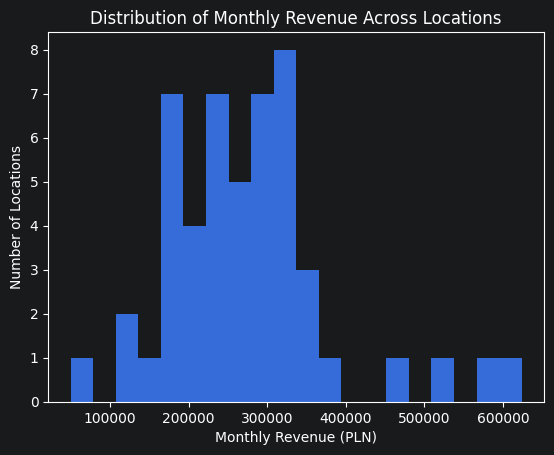

In [7]:
import matplotlib.pyplot as plt

plt.hist(ds_locations['monthly_revenue'], bins=20)
plt.xlabel('Monthly Revenue (PLN)')
plt.ylabel('Number of Locations')
plt.title('Distribution of Monthly Revenue Across Locations')
plt.show()

In [66]:
mean_revenue = ds_locations['monthly_revenue'].mean()
std_revenue = ds_locations['monthly_revenue'].std()

outliers = ds_locations[
    (ds_locations['monthly_revenue'] < mean_revenue - 2 * std_revenue) |
    (ds_locations['monthly_revenue'] > mean_revenue + 2 * std_revenue)
].copy()
outliers['deviation'] = ((outliers['monthly_revenue'] - mean_revenue) / std_revenue).round(2)

print(f"Mean: {mean_revenue:,.2f} | Std: {std_revenue:,.2f}")
print(f"Bounds: [{mean_revenue - 2 * std_revenue:,.2f}, {mean_revenue + 2 * std_revenue:,.2f}]")
print(f"\n{len(outliers)} outlier(s) found:")
outliers

Mean: 275,269.40 | Std: 108,052.30
Bounds: [59,164.81, 491,374.00]

4 outlier(s) found:


,location_id,lat,lng,monthly_revenue,deviation
6,LOC_007,50.283699,19.017317,526630.01,2.33
18,LOC_019,50.261991,19.026051,623866.24,3.23
32,LOC_033,50.280179,19.565872,50000.00,-2.08
42,LOC_043,50.253639,19.039906,573546.91,2.76


Monthly Revenue Across Locations follows roughly normal distribution, with 4 outliers. We will keep them: such revenue values, from 50k to 624k PLN per month, are realistic for grocery stores in Poland — from small local shops to larger stores in busy areas.
Revenue differences are important for our final model, because they may reflect real differences between locations that we aim to identify and explain.
The dataset has only about 50 locations, so removing 4 observations would mean losing around 8% of the data, which is quite significant.  

In [8]:
import geopandas as gpd

gdf_locations = gpd.GeoDataFrame(
    ds_locations,
    geometry=gpd.points_from_xy(ds_locations['lng'], ds_locations['lat']),
    crs="EPSG:4326"
)

Each dataframe will be immediately converted into GeoDataFrame for further visual analysis.

#### ds_competitors

In [9]:
ds_competitors = pd.read_csv(CSV_PATH + "ds_competitors.csv")

In [10]:
ds_competitors

,comp_id,brand,lat,lng
0,COMP_0001,Żabka,50.026907,20.048469
1,COMP_0002,Żabka,50.165093,18.882509
2,COMP_0003,Żabka,50.040923,19.923803
3,COMP_0004,Żabka,50.281506,19.146439
4,COMP_0005,Żabka,50.073621,20.025068
...,...,...,...,...
93,COMP_0094,Lewiatan,50.081776,19.999802
94,COMP_0095,Lewiatan,50.296087,19.478945
95,COMP_0096,Lewiatan,49.973710,18.946176
96,COMP_0097,Lewiatan,50.015953,19.950962


In [11]:
ds_competitors.info()
ds_competitors.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   comp_id  98 non-null     object 
 1   brand    98 non-null     object 
 2   lat      98 non-null     float64
 3   lng      98 non-null     float64
dtypes: float64(2), object(2)
memory usage: 3.2+ KB


,lat,lng
count,98.000000,98.000000
mean,50.180113,19.308845
std,0.124799,0.491663
min,49.972826,18.569767
25%,50.077520,18.910427
50%,50.164636,19.133913
75%,50.287737,19.921517
max,50.451751,20.106234


In [12]:
print("Missing values in ds_competitors:")
print(ds_competitors.isnull().sum())

Missing values in ds_competitors:
comp_id    0
brand      0
lat        0
lng        0
dtype: int64


In [13]:
total_no_of_competitor_locations = ds_competitors['comp_id'].nunique()
counts = ds_competitors['brand'].value_counts()
no_of_competitor_locations = pd.DataFrame({
    'brand': counts.index,
    'count': counts.values,
    'percentage': (counts.values / total_no_of_competitor_locations * 100).round(1)
})
print(f"Number of unique competitor locations: {total_no_of_competitor_locations}")
no_of_competitor_locations

Number of unique competitor locations: 98


,brand,count,percentage
0,Żabka,60,61.2
1,Lewiatan,13,13.3
2,Lidl,6,6.1
3,Dino,4,4.1
4,Carrefour,4,4.1
5,Netto,3,3.1
6,Stokrotka,3,3.1
7,Aldi,3,3.1
8,Kaufland,2,2.0


In [14]:
gdf_competitors = gpd.GeoDataFrame(
    ds_competitors,
    geometry=gpd.points_from_xy(ds_competitors['lng'], ds_competitors['lat']),
    crs="EPSG:4326"
)

#### ds_poi

In [15]:
ds_poi = pd.read_csv(CSV_PATH + "ds_poi.csv")

In [16]:
ds_poi

,poi_id,category,name,lat,lng
0,POI_0001,restaurant,Akira Sushi,50.444306,18.854625
1,POI_0002,restaurant,Za furtką,50.007247,20.012085
2,POI_0003,restaurant,Stodoła,50.060185,19.836112
3,POI_0004,restaurant,Dworek Białoprądnicki,50.092904,19.940781
4,POI_0005,restaurant,Pierwsze piętro,50.062469,19.935316
...,...,...,...,...,...
330,POI_0331,mall,Centrum Handlowe Żory,50.033993,18.683666
331,POI_0332,mall,Galeria PIK,50.167506,18.904237
332,POI_0333,mall,CHU Planeta,50.229642,18.663544
333,POI_0334,mall,Centrum Handlowe Max,50.141884,19.413357


In [17]:
ds_poi.info()
ds_poi.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   poi_id    335 non-null    object 
 1   category  335 non-null    object 
 2   name      335 non-null    object 
 3   lat       335 non-null    float64
 4   lng       335 non-null    float64
dtypes: float64(2), object(3)
memory usage: 13.2+ KB


,lat,lng
count,335.000000,335.000000
mean,50.198706,19.286006
std,0.134370,0.488071
min,49.961147,18.546817
25%,50.071398,18.904120
50%,50.214649,19.134389
75%,50.304197,19.877788
max,50.478774,20.091541


In [18]:
print("Missing values in ds_poi:")
print(ds_poi.isnull().sum())

Missing values in ds_poi:
poi_id      0
category    0
name        0
lat         0
lng         0
dtype: int64


In [19]:
total_number_of_poi = ds_poi['poi_id'].nunique()
counts = ds_poi['category'].value_counts()
number_of_poi = pd.DataFrame({
    'category': counts.index,
    'count': counts.values,
    'percentage': (counts.values / total_number_of_poi * 100).round(1)
})
print(f"Number of unique points of interest: {total_number_of_poi}")
number_of_poi

Number of unique points of interest: 335


,category,count,percentage
0,restaurant,60,17.9
1,school,60,17.9
2,bus_stop,60,17.9
3,park,40,11.9
4,pharmacy,40,11.9
5,bank,30,9.0
6,hospital,30,9.0
7,mall,15,4.5


In [20]:
gdf_poi = gpd.GeoDataFrame(
    ds_poi,
    geometry=gpd.points_from_xy(ds_poi['lng'], ds_poi['lat']),
    crs="EPSG:4326"
)

#### ds_analysis_area

In [21]:
ds_analysis_area = pd.read_csv(CSV_PATH + "ds_analysis_area.csv")

In [22]:
ds_analysis_area

,area_name,geometry
0,Silesia-Kraków Metropolitan Area,"POLYGON ((18.540000 50.420000, 18.560000 50.45..."


In [23]:
ds_analysis_area.info()
ds_analysis_area.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   area_name  1 non-null      object
 1   geometry   1 non-null      object
dtypes: object(2)
memory usage: 144.0+ bytes


,area_name,geometry
count,1,1
unique,1,1
top,Silesia-Kraków Metropolitan Area,"POLYGON ((18.540000 50.420000, 18.560000 50.45..."
freq,1,1


In [24]:
from shapely import wkt

ds_analysis_area['geometry'] = ds_analysis_area['geometry'].apply(wkt.loads)
gdf_area = gpd.GeoDataFrame(ds_analysis_area, geometry='geometry', crs="EPSG:4326")

#### ds_districts

In [26]:
ds_districts = pd.read_csv(CSV_PATH + "ds_districts.csv")

In [27]:
ds_districts

,district_id,name,geometry
0,2401,Katowice,"POLYGON ((18.935000 50.256400, 18.924467 50.24..."
1,2402,Sosnowiec,"POLYGON ((19.061400 50.285867, 19.066667 50.27..."
2,2403,Gliwice,"POLYGON ((18.540000 50.282400, 18.540000 50.26..."
3,2404,Kraków,"POLYGON ((19.851400 50.057067, 19.840867 50.04..."
4,2405,Tychy,"POLYGON ((18.787533 50.114267, 18.798067 50.11..."
5,2406,Chrzanów,"POLYGON ((19.319467 50.128133, 19.314200 50.11..."
6,2407,Oświęcim,"POLYGON ((19.098267 50.020667, 19.093000 50.00..."
7,2408,Olkusz,"POLYGON ((19.419533 50.280667, 19.435333 50.26..."
8,2409,Rybnik,"POLYGON ((18.540000 50.102133, 18.540000 50.10..."
9,2410,Dąbrowa Górnicza,"POLYGON ((19.135133 50.329200, 19.140400 50.32..."


In [28]:
ds_districts.info()
ds_districts.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   district_id  15 non-null     int64 
 1   name         15 non-null     object
 2   geometry     15 non-null     object
dtypes: int64(1), object(2)
memory usage: 488.0+ bytes


,district_id
count,15.000000
mean,2408.000000
std,4.472136
min,2401.000000
25%,2404.500000
50%,2408.000000
75%,2411.500000
max,2415.000000


In [29]:
print("Missing values in ds_districts:")
print(ds_districts.isnull().sum())

Missing values in ds_districts:
district_id    0
name           0
geometry       0
dtype: int64


In [30]:
ds_districts['geometry'] = ds_districts['geometry'].apply(wkt.loads)
gdf_districts = gpd.GeoDataFrame(ds_districts, geometry='geometry', crs="EPSG:4326")

#### Bbox and visualization

In [33]:
analysis_area = gdf_area['geometry'].iloc[0]
bbox = analysis_area.bounds
print(f"Bbox of analysis area: {bbox}")
print(f"Longitude: {bbox[0]:.4f} - {bbox[2]:.4f}")
print(f"Latitude: {bbox[1]:.4f} - {bbox[3]:.4f}")

ANALYSIS_BBOX = {
    'lng_min': bbox[0],
    'lat_min': bbox[1],
    'lng_max': bbox[2],
    'lat_max': bbox[3]
}

Bbox of analysis area: (18.54, 49.96, 20.12, 50.48)
Longitude: 18.5400 - 20.1200
Latitude: 49.9600 - 50.4800


We identified the bbox of our analyzed area. It will be saved in a JSON format for reference.

In [67]:
import json
from pathlib import Path

path = Path("../data/processed/analysis_bbox.json")
path.parent.mkdir(parents=True, exist_ok=True)
with path.open('w') as f:
    json.dump(ANALYSIS_BBOX, f, indent=2)

In [59]:
import folium

centroid = analysis_area.centroid
map_1 = folium.Map(location=[centroid.y, centroid.x], zoom_start=10)

In [60]:
folium.GeoJson(
    gdf_area,
    name='Analysis Area',
    style_function=lambda x: {'color': 'black', 'weight': 2, 'fillOpacity': 0.05}
).add_to(map_1)

In [61]:
for _, row in gdf_locations.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=6,
        color='red',
        fill=True,
        fillColor='red',
        popup=f"Revenue: {row['monthly_revenue']:.0f} PLN"
    ).add_to(map_1)

In [62]:
map_1

In [65]:
locations_inside = gdf_locations[gdf_locations.within(analysis_area)]
locations_outside = gdf_locations[~gdf_locations.within(analysis_area)]

print(f"Inside: {len(locations_inside)}")
print(f"Outside: {len(locations_outside)}")

if len(locations_outside) > 0:
    print("Locations outside the analysis area:")
    print(locations_outside)

Inside: 47
Outside: 3
Locations outside the analysis area:
   location_id        lat        lng  monthly_revenue  \
10     LOC_011  50.121043  18.548470        306718.03   
24     LOC_025  49.994134  20.053555        231470.22   
39     LOC_040  49.965208  18.956704        130489.86   

                     geometry  
10  POINT (18.54847 50.12104)  
24  POINT (20.05356 49.99413)  
39   POINT (18.9567 49.96521)  
